# Notebook 04 — Information Entities

## Overview

So far we have modelled *things that exist in the world*: pizzas, ingredients, and the processes that create and transform them. But the world also contains a second, fundamentally different kind of entity — **information objects**: things whose primary function is to carry meaning *about* something else.

When you place a pizza order, the restaurant creates a record of what was requested. That record has no flavour, no crust, no toppings. Its identity is defined by its content — what it says — not by any physical properties.

SULO captures this distinction with the `sulo:InformationObject` class. Information objects are linked to the things they describe via `sulo:refersTo`, enabling defined classes whose membership is determined by what an object *represents* rather than what it physically *is*.

## Learning Objectives

1. Distinguish `sulo:InformationObject` from `sulo:SpatialObject` and explain why the distinction matters ontologically
2. Structure information objects using nested parts: an `OrderIdentifier` carrying a string value, a `sulo:Collection` of `sulo:Quantity` items each referring to a pizza type
3. Create named individuals, annotate them with `rdfs:label` and `rdfs:comment`, and link them to the entities they describe via `sulo:refersTo`
4. Contrast primitive classes (`is_a`) with defined classes (`equivalent_to`), and use `refersTo` restrictions to trigger automatic classification by the reasoner
5. Model a recipe as an `InformationObject` that `refersTo` a temporally ordered process, and verify that a plain individual is classified automatically

## Getting started

The following cell loads SULO, the `pro` ontology, and the pizza ontology built in notebook 03.

In [1]:
import sys, os
# Locate project root (the directory containing lib/) regardless of CWD
for _p in ['.', '..', '../..']:
    if os.path.isdir(os.path.join(_p, 'lib')):
        os.chdir(_p); sys.path.insert(0, os.getcwd()); break
    
from lib.helpers import *
onto_path.append(".")
sulo = get_ontology("dist/sulo.owl").load()  # RDF/XML
pro = get_ontology("dist/pro.owl").load()
pizza = get_ontology("dist/pizza-03.owl").load()
pizza.imported_ontologies.append(sulo)
pizza.imported_ontologies.append(pro)

result = safe_call_reasoner(pizza)
print("Consistent:", result["ok"])

Consistent: True


## Defining Information Entity Classes

We introduce two subclasses of `sulo:InformationObject`:

- `Order` — an information object encoding a customer's request
- `OrderIdentifier` — a nested `sulo:InformationObject` that carries the order's string ID via `sulo:hasValue`

SULO's `refersTo` object property links an information object to the entity it represents.

In [2]:
with pizza:
    class Order(sulo.InformationObject):
        """An information object encoding a customer request for an item offered by the vendor."""
        label = [locstr("order", "en")]

    class OrderIdentifier(sulo.InformationObject):
        """A unique string identifier assigned to an order."""
        label = [locstr("order identifier", "en")]

result = safe_call_reasoner(pizza)
print("Ontology consistent:", result["ok"])
print("Inconsistent classes:", result["inconsistent"])

Ontology consistent: True
Inconsistent classes: []


## Creating Individuals

In OWL, **individuals** (also called *instances* or *ABox assertions*) are named entities that belong to one or more classes. Unlike classes — which describe sets — an individual represents a specific, uniquely identified thing.

In owlready2, an individual is created by calling the class like a constructor:

```python
order_001 = Order("order_001")
```

The string `"order_001"` becomes the local name in the ontology IRI. Annotation properties (`label`, `comment`) are inherited from `rdfs:label` and `rdfs:comment`.

In [3]:
with pizza:
    order_001 = Order("order_001")
    order_001.label   = ["Pizza Order #001"]
    order_001.comment = ["Order for a Traditional Four Cheese Pizza and a Spicy Salami Pizza."]

    # The order has a string identifier as a nested InformationObject part
    id_001 = OrderIdentifier("id_001")
    id_001.hasValue = "ORDER-001"

    # Each line item is a sulo:Quantity — it encodes *how many* via hasValue, and
    # *what kind* via an anonymous class assertion (is_a refersTo some PizzaType).
    # Using Quantity rather than a direct refersTo on the order preserves the count
    # and allows multiple items of the same type to be distinguished.
    item_001 = sulo.Quantity("item_001")
    item_001.label    = "1x Traditional Four Cheese Pizza"
    item_001.hasValue = 1
    item_001.is_a     = [sulo.refersTo.some(pizza.TraditionalFourCheesePizza)]

    item_002 = sulo.Quantity("item_002")
    item_002.label    = "1x Spicy Pizza"
    item_002.hasValue = 1
    item_002.is_a     = [sulo.refersTo.some(pizza.SpicyPizza)]

    # Collect the items and attach everything to the order in one assignment
    collection_001 = sulo.Collection("order_items_001")
    collection_001.hasItem = [item_001, item_002]
    order_001.hasPart = [id_001, collection_001]

result = safe_call_reasoner(pizza)
print("Ontology consistent:", result["ok"])
print("Inconsistent classes:", result["inconsistent"])

Ontology consistent: True
Inconsistent classes: []


## Defined Classes for Information Entities

Just as we defined `SpicyPizza` using quality restrictions, we can define information-entity classes in terms of what they are *about*. A `SpicyPizzaOrder` is an `Order` that `refersTo` some `SpicyPizza`.

To trigger the classification, we create a `SpicySalamiPizza` individual — representing the actual pizza the kitchen made — and assert that `order_001` refers to it. Since `SpicySalamiPizza` is a subclass of `SpicyPizza` (from notebook 02), the `equivalent_to` condition is satisfied and the reasoner will classify `order_001` as a `SpicyPizzaOrder`.

In [4]:
with pizza:
    # The declared parent (Order) is technically redundant with the equivalent_to
    # expression below, which already implies Order as a superclass. Both are kept
    # here for readability: the declaration makes the hierarchy explicit at a glance;
    # the equivalent_to states the full necessary and sufficient condition.
    class SpicyPizzaOrder(Order):
        """A pizza order that refers to a SpicyPizza."""
        label = [locstr("order for spicy pizza", "en")]
        equivalent_to = [Order & sulo.refersTo.some(pizza.SpicyPizza)]

    pizza_001 = pizza.SpicySalamiPizza("spicy_salami_pizza_001")
    order_001.refersTo.append(pizza_001)

result = safe_call_reasoner(pizza)
print("Ontology consistent:", result["ok"])
print("Inconsistent classes:", result["inconsistent"])
print("order_001 inferred types:", [t for t in order_001.is_a if hasattr(t, 'name')])

Ontology consistent: True
Inconsistent classes: []
order_001 inferred types: [pizza-03.SpicyPizzaOrder]


The classification follows from the chain:

1. `spicy_salami_pizza_001` is asserted as a `SpicySalamiPizza`
2. `SpicySalamiPizza` is a subclass of `SpicyPizza` (defined in notebook 02)
3. `order_001.refersTo` now contains `spicy_salami_pizza_001`
4. `SpicyPizzaOrder ≡ Order & refersTo some SpicyPizza` — the condition is met
5. Therefore: `order_001` is inferred to be a `SpicyPizzaOrder`

Note that `order_001` was created before `SpicyPizzaOrder` was even defined. OWL reasoning is non-procedural: the reasoner considers all asserted facts simultaneously and applies all applicable class definitions at once.

Having linked an order to what it is *about*, we now apply the same `refersTo` pattern at a higher level — linking a recipe to the process it describes.

## Recipe to Realization

A pizza recipe is an `InformationObject` — it specifies the set of steps to make a pizza. The thing it describes is a process: specifically, the full sequence of pizza-making steps from mixing dough to slicing.

Notebook 03 defined the individual step classes (`MakingThePizzaDough`, `ProofingTheDough`, …) and their `precedes` ordering. Here we wrap them into a single class, `PizzaMakingProcess`, so that the entire pipeline can be referenced as a named whole — which is what a recipe needs to point to.

We model this with two classes:

- `PizzaMakingProcess` — uses `is_a` (necessary conditions only): any process with these parts qualifies, but we do not want every process with these parts to be *automatically reclassified* from other ontologies.
- `PizzaRecipe` — uses `equivalent_to` (necessary *and* sufficient): any `InformationObject` that `refersTo` a `PizzaMakingProcess` individual should be automatically classified as a recipe. The defined form is chosen here precisely because that automatic classification is the point.

We then create `making_001`, an individual of `PizzaMakingProcess`, and `recipe_001`, a plain `sulo.InformationObject` that refers to it. The reasoner will classify `recipe_001` as a `PizzaRecipe` without any explicit type assertion.

> Note: `making_001` satisfies its class membership under the Open World Assumption — the reasoner does not require the sub-process parts to be asserted on the individual unless there is a closed-world constraint forcing it to do so.

In [5]:
with pizza:
    class PizzaMakingProcess(sulo.Process):
        """The complete pizza-making process, composed of all pipeline sub-processes in temporal order."""
        label = [locstr("pizza making process", "en")]
        is_a = [
            sulo.hasPart.some(pizza.MakingThePizzaDough & sulo.precedes.some(pizza.ProofingTheDough)),
            sulo.hasPart.some(pizza.ProofingTheDough    & sulo.precedes.some(pizza.AssemblingThePizza)),
            sulo.hasPart.some(pizza.AssemblingThePizza  & sulo.precedes.some(pizza.BakingThePizza)),
            sulo.hasPart.some(pizza.BakingThePizza      & sulo.precedes.some(pizza.SlicingThePizza)),
            sulo.hasPart.some(pizza.SlicingThePizza),
        ]

    class PizzaRecipe(sulo.InformationObject):
        """An information object that specifies the complete pizza-making process."""
        label = [locstr("pizza recipe", "en")]
        equivalent_to = [sulo.InformationObject & sulo.refersTo.some(PizzaMakingProcess)]

    # Realization: a specific recipe individual referring to a specific process individual
    making_001 = PizzaMakingProcess("making_001")

    recipe_001 = sulo.InformationObject("recipe_001")
    recipe_001.label    = ["Traditional Neapolitan Pizza Recipe"]
    recipe_001.refersTo = [making_001]

result = safe_call_reasoner(pizza)
print("Consistent:", result["ok"])
print("Inconsistent classes:", result["inconsistent"])


Consistent: True
Inconsistent classes: []


`recipe_001` was declared as a plain `sulo.InformationObject` — no explicit type assertion as `PizzaRecipe`. Because it `refersTo` a `PizzaMakingProcess` individual, the reasoner applies the `equivalent_to` condition and classifies it automatically:

In [6]:
inferred = [t for t in recipe_001.is_a if hasattr(t, 'name')]
print("recipe_001 inferred types:", inferred)

recipe_001 inferred types: [pizza-03.PizzaRecipe]


Saved pizza-04.owl


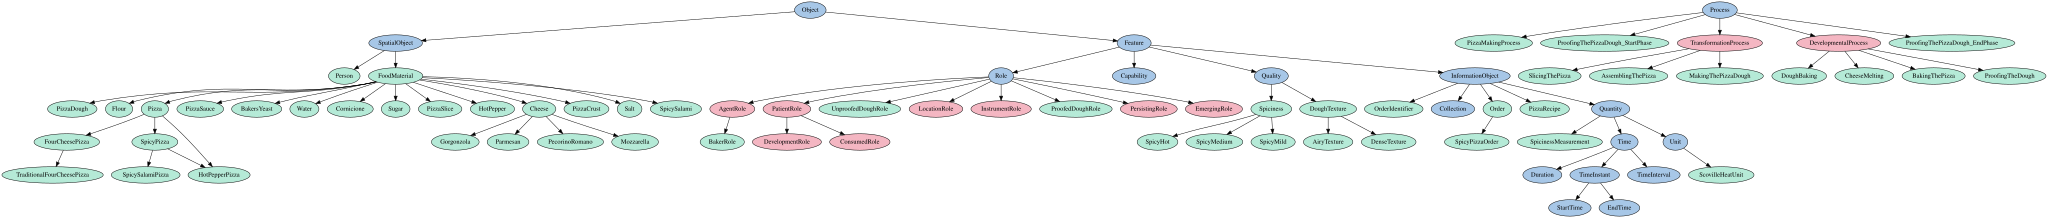

In [7]:
pizza.save(file="dist/pizza-04.owl", format="rdfxml")
print("Saved pizza-04.owl")
display(get_color_tree([sulo, pro, pizza]))

---

### YOUR TURN — `NutritionalLabel`

Food products carry nutritional labels — information objects that describe the properties of the food they are attached to.

- Define `NutritionalLabel` as a subclass of `sulo:InformationObject` with `equivalent_to` set to `InformationObject & refersTo some FoodMaterial`
- Define `CalorieCount` as a subclass of `sulo:Quantity`
- Create a `NutritionalLabel` individual for a `PizzaSlice`: attach a `CalorieCount` individual to it via `hasFeature`, and set the calorie value via `hasValue`
- Run the reasoner and verify the individual is classified as `NutritionalLabel`

> `FoodMaterial` and `PizzaSlice` were defined in notebook 03 — refer to that notebook's summary table if you need the exact class names.

In [8]:
# YOUR TURN — your code here

---

## Summary

In this notebook we introduced `sulo:InformationObject` as a second top-level kind alongside `sulo:SpatialObject`, and modelled the information artefacts that accompany the pizza-making pipeline.

### What we built

**Classes**

| Class | Parent | Description |
|---|---|---|
| `Order` | `sulo:InformationObject` | encodes a customer request |
| `OrderIdentifier` | `sulo:InformationObject` | carries a string order ID via `hasValue` |
| `SpicyPizzaOrder` | `Order` | an order that refers to a spicy pizza (defined) |
| `PizzaMakingProcess` | `sulo:Process` | the full pipeline with temporally ordered sub-process parts (primitive) |
| `PizzaRecipe` | `sulo:InformationObject` | an information object that refers to a pizza-making process (defined) |

**Defined classes**

| Class | Definition |
|---|---|
| `SpicyPizzaOrder` | `Order & refersTo some SpicyPizza` |
| `PizzaRecipe` | `InformationObject & refersTo some PizzaMakingProcess` |

**Individuals**

| Individual | Type | Key assertions |
|---|---|---|
| `order_001` | `Order` → inferred `SpicyPizzaOrder` | `hasPart` id + collection; `refersTo` spicy salami pizza |
| `making_001` | `PizzaMakingProcess` | declared type only |
| `recipe_001` | plain `InformationObject` → inferred `PizzaRecipe` | `refersTo making_001` |

### Key concepts

**`InformationObject` vs `SpatialObject`.** A spatial object occupies space and has physical properties; an information object carries content about something else. An order and the pizza it describes are ontologically distinct kinds of entity.

**`refersTo` as the bridge.** `sulo:refersTo` links an information object to the entity it is about. Defined classes built on `refersTo` restrictions classify information objects by what they *represent*, not what they physically are.

**Primitive vs defined classes.** `PizzaMakingProcess` uses `is_a`: the axioms are necessary conditions, but the class is not automatically applied to individuals from other ontologies that happen to satisfy them. `PizzaRecipe` uses `equivalent_to`: the conditions are necessary *and* sufficient, so any `InformationObject` referring to a `PizzaMakingProcess` is automatically classified — regardless of where or how it was declared.

**OWL reasoning is non-procedural.** The reasoner applies all class definitions simultaneously to all asserted facts. An individual created before a defined class was added can still be classified by it.

**Open World Assumption.** `making_001` is declared as a `PizzaMakingProcess` without its sub-process parts asserted. The reasoner accepts this: under the OWA, absence of an assertion does not mean the fact is false.

### What comes next

Notebook 05 covers **time** — representing temporal intervals, durations, and process anchoring using SULO's `Time` hierarchy and `atTime`.